In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split,GridSearchCV,RandomizedSearchCV,cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import fetch_california_housing,load_breast_cancer

# 评价指标
from sklearn.metrics import (
    mean_absolute_error,mean_squared_error,r2_score,accuracy_score,precision_score,
    recall_score,f1_score,roc_auc_score,roc_curve,confusion_matrix,classification_report
)

# 中文显示设置
plt.rcParams['font.sans-serif']=['SimHei','Arial Unicode MS']
plt.rcParams['axes.unicode_minus']=False

# 固定随机种子,保证结果可复现
RANDOM_STATE=42

### 一.回归任务

* 回归任务公共操作

In [3]:
# 加载加州房价数据集
reg_data=fetch_california_housing()
X_reg=pd.DataFrame(reg_data.data,columns=reg_data.feature_names) #特征
y_reg=reg_data.target

# 数据集划分
# 训练集80%，测试集20%;固定随机种子,保证可复现
X_reg_train,X_reg_test,y_reg_train,y_reg_test=train_test_split(
    X_reg,y_reg,test_size=0.2,random_state=RANDOM_STATE
)

# 标准化
# 树模型(RF/XGB/LGBM/AdaBoost)不需要标准化,但线性回归需要
# 在训练集上fit,在测试集上transform,避免数据泄露
scaler=StandardScaler()
X_reg_train_scaled=scaler.fit_transform(X_reg_train)
X_reg_test_scaled=scaler.transform(X_reg_test)


* 了解基础数据

In [4]:
X_reg.head(3)

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24


In [5]:
y_reg[:3]

array([4.526, 3.585, 3.521])

##### 1.线性回归

Ridge最优参数alpha:{'alpha': 0.1}
线性回归:MAE=0.5332,MSE=0.5559,R2=0.3376


C:\Users\11146\AppData\Local\Temp\ipykernel_13740\4034499261.py:37: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(x=y_reg_test,y=y_pred_lr,ax=ax1,palette='viridis',alpha=0.3)


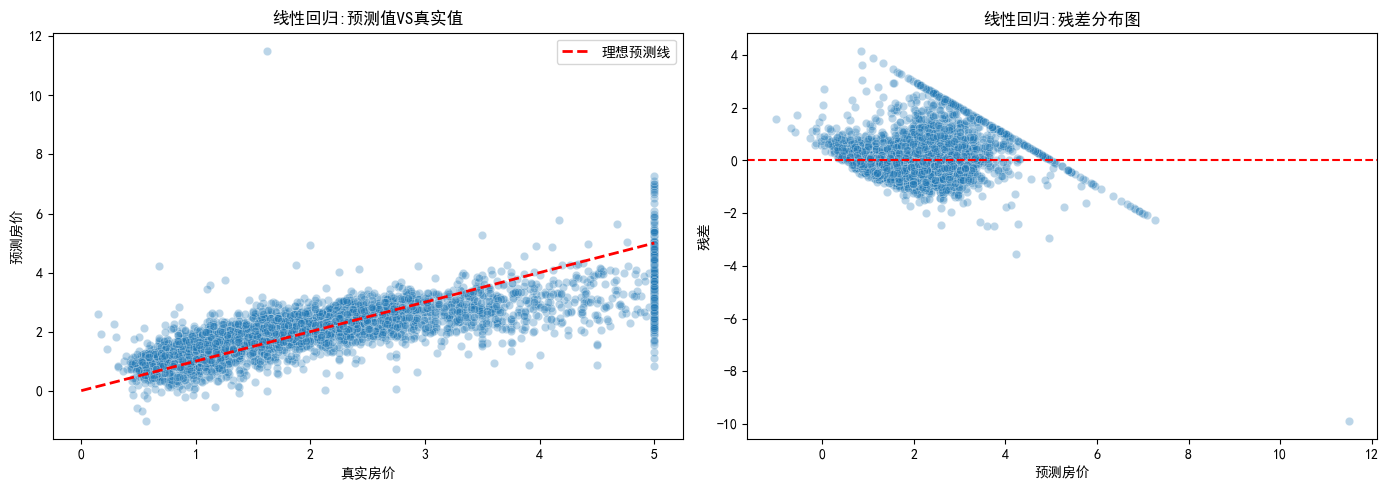

In [6]:
from sklearn.linear_model import LinearRegression,Ridge   #调参通过正则化实现

# 1.训练基础模型
lr=LinearRegression()   #采用OLS最小二乘法,不需要设置随机数种子
lr.fit(X_reg_train_scaled,y_reg_train)   # 线性回归必须要用标准化后的特征
y_pred_lr=lr.predict(X_reg_test_scaled)

# 2.调参方法
# 线性回归本身无超参数可调
# 实际工程中通过Ridge(L2正则化)/L1(L1正则化)来'调参'——调整正则强度alpha
ridge_params={'alpha':[0.001,0.01,0.1,1,10,100]}   # 候选正则强度
ridge_grid=GridSearchCV(
    Ridge(random_state=RANDOM_STATE),
    ridge_params,
    cv=5,   # 五折交叉验证
    scoring='neg_mean_squared_error',   # 负均方误差,因为GridSearchCV默认是最大化指标,所以取负号
    n_jobs=-1
)
ridge_grid.fit(X_reg_train_scaled,y_reg_train)
y_pred_ridge=ridge_grid.predict(X_reg_test_scaled)
print(f'Ridge最优参数alpha:{ridge_grid.best_params_}')
best_lr=ridge_grid.best_estimator_   # 获取最优模型
y_pred_lr=best_lr.predict(X_reg_test_scaled)   # 使用最优模型预测

# 3.评价指标
mae_lr=mean_absolute_error(y_pred_lr,y_reg_test)
mse_lr=mean_squared_error(y_pred_lr,y_reg_test)
r2_lr=r2_score(y_pred_lr,y_reg_test)
print(f'线性回归:MAE={mae_lr:.4f},MSE={mse_lr:.4f},R2={r2_lr:.4f}')

# 可视化
fig=plt.figure(figsize=(14,5))
ax1=plt.subplot(121)   # 第一幅图:预测值VS真实值散点图
ax2=plt.subplot(122)   # 第二幅图:残差分布图(应近似随机分布)

# 第一幅图:预测值VS真实值散点图
sns.scatterplot(x=y_reg_test,y=y_pred_lr,ax=ax1,palette='viridis',alpha=0.3)
ax1.plot([0,5],[0,5],ls='--',color='r',lw=2,label='理想预测线')   # 对角参考线
ax1.set_xlabel('真实房价')
ax1.set_ylabel('预测房价')
ax1.set_title('线性回归:预测值VS真实值')
ax1.legend()

# 第二幅图:残差分布图
resid=y_reg_test-y_pred_lr
sns.scatterplot(x=y_pred_lr,y=resid,alpha=0.3,ax=ax2)
ax2.axhline(y=0,color='r',ls='--')   # 残差为0的参考线
ax2.set_xlabel('预测房价')
ax2.set_ylabel('残差')
ax2.set_title('线性回归:残差分布图')

plt.tight_layout()

* 结论:标签房价和部分特征存在非线性关系难以拟合,同时存在异常值/极端值干扰模型

##### 2.随机森林

Fitting 5 folds for each of 20 candidates, totalling 100 fits
RF最优参数:{'n_estimators': 300, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': None}
随机森林:MAE=0.3205
随机森林:MSE=0.2406
随机森林:R²=0.7512


C:\Users\11146\AppData\Local\Temp\ipykernel_13740\1262900398.py:42: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(x=y_reg_test,y=y_pred_rf,ax=ax1,palette='husl',alpha=0.3)


<Axes: ylabel='None'>

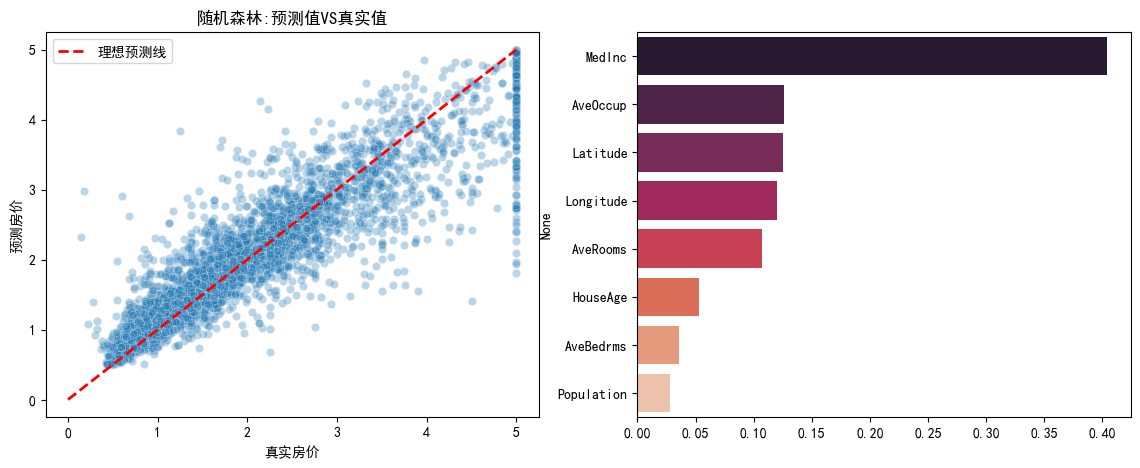

In [13]:
from sklearn.ensemble import RandomForestRegressor

# 1.训练基础模型(树模型不需要标准化,直接用原始特征)
rf_reg=RandomForestRegressor(n_estimators=100,n_jobs=-1,random_state=RANDOM_STATE)
rf_reg.fit(X_reg_train,y_reg_train)

# 2.调参方法(RandomizedSearchCV随机搜索)
# 关键超参数说明:①min_samples_split:节点分裂所需最小样本数 ②min_samples_leaf:叶子节点最小样本数 ③max_features:每棵树随机选择的特征数
rf_params={
    'n_estimators':[100,200,300,500],   # 树的数量
    'max_depth':[None,10,15,20],   # 树的最大深度
    'min_samples_split':[2,5,10],   # 节点分裂所需最小样本数
    'min_samples_leaf':[1,2,4],   # 叶子节点最小样本数
    'max_features':['sqrt','log2']   # 每棵树随机选择的特征数
}
rf_search=RandomizedSearchCV(
    RandomForestRegressor(n_jobs=-1,random_state=RANDOM_STATE),
    rf_params,
    n_iter=20,   # 随机搜索20次
    cv=5,   # 五折交叉验证
    scoring='neg_mean_squared_error',   # 负均方误差
    n_jobs=-1,
    random_state=RANDOM_STATE,
    verbose=2   # 打印两个关键信息
)
rf_search.fit(X_reg_train,y_reg_train)
print(f'RF最优参数:{rf_search.best_params_}')
best_rf=rf_search.best_estimator_
y_pred_rf=best_rf.predict(X_reg_test)

# 3.评价指标
print(f'随机森林:MAE={mean_absolute_error(y_pred_rf,y_reg_test):.4f}')
print(f'随机森林:MSE={mean_squared_error(y_pred_rf,y_reg_test):.4f}')
print(f'随机森林:R²={r2_score(y_pred_rf,y_reg_test):.4f}')

# 4.可视化
fig=plt.figure(figsize=(14,5))
ax1=plt.subplot(121)   # 第一幅图:预测值VS真实值散点图
ax2=plt.subplot(122)   # 第二幅图:特征重要性条形图

# 第一幅图:预测值VS真实值散点图
sns.scatterplot(x=y_reg_test,y=y_pred_rf,ax=ax1,palette='husl',alpha=0.3)
ax1.plot([0,5],[0,5],ls='--',color='r',lw=2,label='理想预测线')   # 对角参考线
ax1.set_xlabel('真实房价')
ax1.set_ylabel('预测房价')
ax1.set_title('随机森林:预测值VS真实值')
ax1.legend()

# 第二幅图:特征重要性条形图
importance=pd.Series(best_rf.feature_importances_,index=X_reg.columns).sort_values(ascending=False)
sns.barplot(x=importance.values,y=importance.index,hue=importance.index,ax=ax2,palette='rocket')

##### 3.XGBoost

In [ ]:
from xgboost import XGBRegressor

# 1.训练基础模型
xgb_reg=XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,   # 单棵树深度
    subsample=0.8,   # 每棵树使用的样本比例
    colsample_bytree=0.8,   # 每棵树使用的特征比例
    random_state=RANDOM_STATE,
    n_jobs=-1
)
xgb_reg.fit(X_reg_train,y_reg_train)

# 2.调参方法
# 关键超参数:①reg_alpha->L1正则项 ②reg_lambda->L2正则项
xgb_params={
    'n_estimators':[100,300,500],
    'learning_rate':[0.01,0.05,0.1,0.2],
    'max_depth':[3,5,7],
    'subsample':[0.7,0.8,1.0],
    'colsample_bytree':[0.7,0.8,1.0],
    'reg_alpha':[0,0.1,1],
    'reg_lambda':[1,5,10]
}
xgb_search=RandomizedSearchCV(
    XGBRegressor(random_state=RANDOM_STATE,n_jobs=-1),
    xgb_params,
    cv=5,
    n_iter=20,
    scoring='neg_mean_squared_error',
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1
)
xgb_search.fit(X_reg_train,y_reg_train)
print(f'XGB最优参数:{xgb_search.best_params_}')
best_xgb=xgb_search.best_estimator_
y_pred_xgb=best_xgb.predict(X_reg_test)

# 3.评价指标
print(f'XGBoost:MAE={y_pred_xgb,y_reg_test}')
print(f'XGBoost:MSE={mean_squared_error(y_pred_xgb,y_reg_test):.4f}')
print(f'XGBoost:R²={r2_score(y_pred_xgb,y_reg_test):.4f}')

# 4.可视化
fig=plt.figure(figsize=(14,5))
ax1=plt.subplot(121)   # 第一幅图:预测值VS真实值散点图
ax2=plt.subplot(122)   # 第二幅图:学习曲线:训练过程中RMSE的变化(观察是否过拟合/欠拟合)

# 第一幅图:预测值VS真实值散点图
sns.scatterplot(x=y_reg_test,y=y_pred_xgb,ax=ax1,alpha=0.3)
ax1.plot([0,5],[0,5],ls='--',color='r',lw=2,label='理想预测线')   # 对角参考线
ax1.set_xlabel('真实房价')
ax1.set_ylabel('预测房价')
ax1.set_title('XGBoost:预测值VS真实值')
ax1.legend()

# 第二幅图:学习曲线图
results=best_xgb.evals_result() if hasattr(best_xgb,'evals_result') else None
eval_set=[(X_reg_train, y_reg_train), (X_reg_test, y_reg_test)]
best_xgb.fit(X_reg_train,y_reg_train,eval_set=eval_set,verbose=False) # verbose=False表示不展示任何日志
ax2.plot(best_xgb.evals_result()['validation_0']['RMSE'],label='训练集RMSE')
ax2.plot(best_xgb.evals_result()['validation_1']['RMSE'],label='测试集RMSE')
ax2.set_xlabels('迭代次数')
ax2.set_ylabels('RMSE')
ax2.set_title('XGBoost:学习曲线')
ax2.legend()
plt.tight_layout()